<a href="https://colab.research.google.com/github/FayezaQareen-TW/PRODIGY_DS_02/blob/main/PRODIGY_DS_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load data
df = pd.read_csv('titanic.csv')

# STEP 1 - Understand data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
print(df.describe())

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Stats:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.

In [10]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],
                      inplace=True)
df.drop('Cabin', axis=1, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_3300/325632370.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3300/325632370.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
# Q1: Overall survival rate
print("Survival Rate:",
      df['Survived'].mean()*100, "%")

# Q2: Survival by gender
print("\nSurvival by Gender:")
print(df.groupby('Sex')['Survived'].mean()*100)

# Q3: Survival by passenger class
print("\nSurvival by Class:")
print(df.groupby('Pclass')['Survived'].mean()*100)

# Q4: Average age by survival
print("\nAverage Age:")
print(df.groupby('Survived')['Age'].mean())

# Q5: Survival by age group
df['AgeGroup'] = pd.cut(df['Age'],
                  bins=[0,12,18,35,60,100],
                  labels=['Child','Teen',
                         'Adult','Middle','Senior'])
print("\nSurvival by Age Group:")
print(df.groupby('AgeGroup')['Survived'].mean()*100)

Survival Rate: 38.38383838383838 %

Survival by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average Age:
Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

Survival by Age Group:
AgeGroup
Child     57.971014
Teen      42.857143
Adult     35.327103
Middle    40.000000
Senior    22.727273
Name: Survived, dtype: float64


/tmp/ipykernel_3300/2020451953.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Survived'].mean()*100)


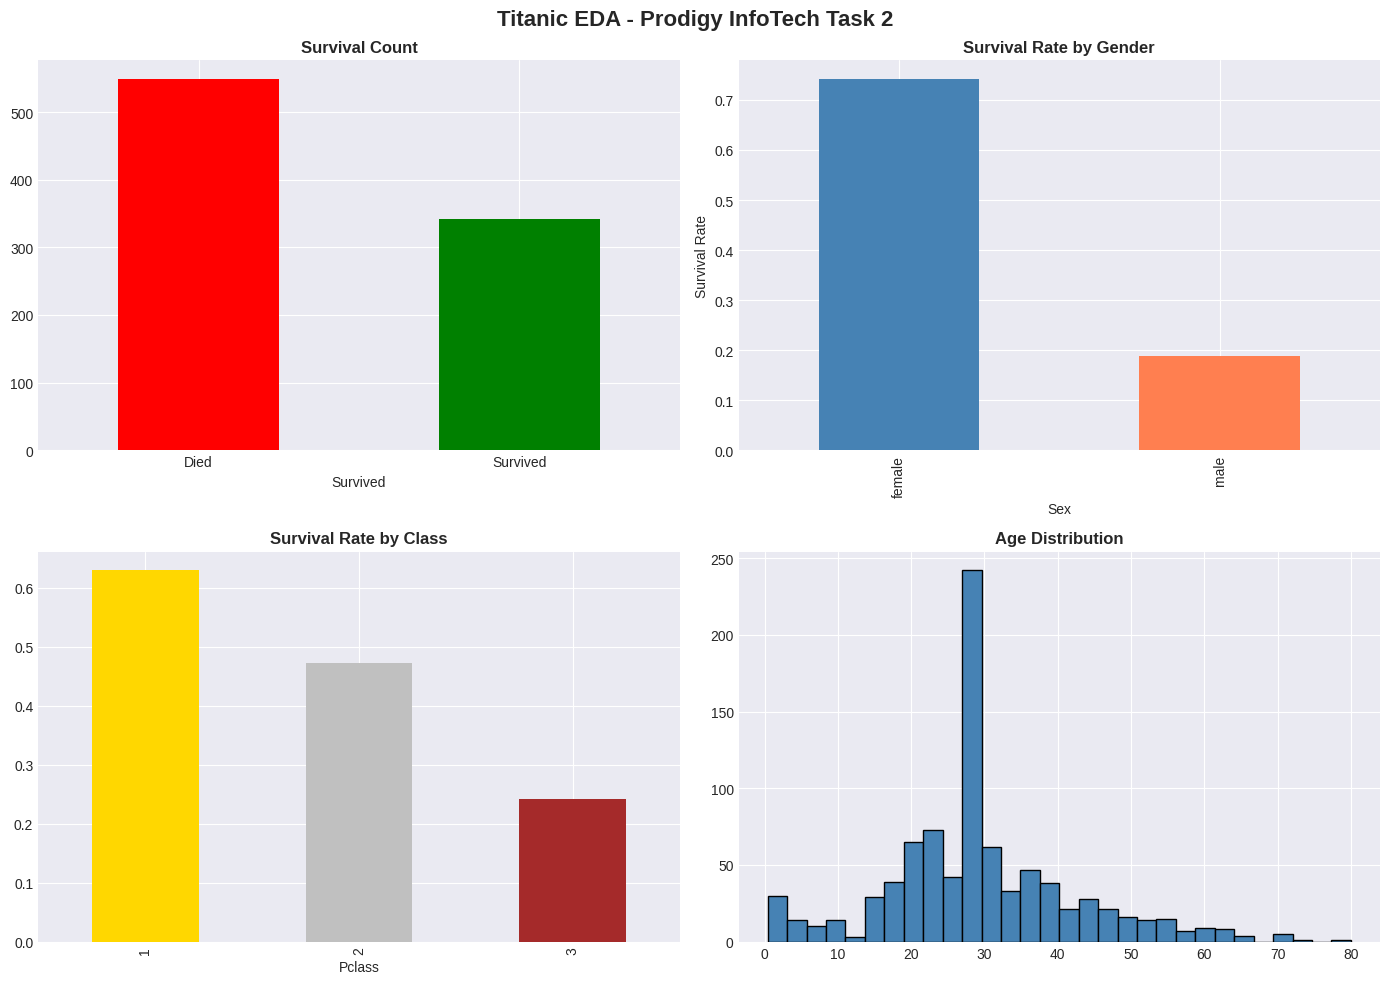

Task 2 Complete! ✅


In [12]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Chart 1 - Survival Count
df['Survived'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=['red','green'])
axes[0,0].set_title('Survival Count',
                     fontweight='bold')
axes[0,0].set_xticklabels(['Died','Survived'],
                            rotation=0)

# Chart 2 - Survival by Gender
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0,1],
    color=['steelblue','coral'])
axes[0,1].set_title('Survival Rate by Gender',
                     fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')

# Chart 3 - Survival by Class
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1,0],
    color=['gold','silver','brown'])
axes[1,0].set_title('Survival Rate by Class',
                     fontweight='bold')

# Chart 4 - Age Distribution
axes[1,1].hist(df['Age'], bins=30,
               color='steelblue',
               edgecolor='black')
axes[1,1].set_title('Age Distribution',
                     fontweight='bold')

plt.suptitle('Titanic EDA - Prodigy InfoTech Task 2',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('titanic_eda.png', dpi=300)
plt.show()
print("Task 2 Complete! ✅")